# Exploratory Data Analysis on Retail Sales Data
### Oasis Infobyte SIP — Data Analytics Track — Level 1, Task 1

**Dataset:** Sample Superstore Dataset (Kaggle)
**Objective:** Perform a thorough EDA on retail sales data to uncover patterns, customer behaviour trends, and actionable business insights.

**Author:** *(add your name)*

---

> **⚠️ Note on scope:** This is a transaction/order-level dataset — it does not include individual customer age or gender fields. In Section 4 ("Customer Demographics Analysis"), I substitute the closest genuine demographic-style fields available — **Customer Segment** and **Region** — rather than fabricate synthetic age/gender data on real transaction records. This is explained again at that section.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('Sample-Superstore.csv', encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Initial Inspection
Check the shape, column data types, and null values before doing anything else.

In [2]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (9994, 21)

Column dtypes:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Null values per column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
d

**Observation:** The dataset has 9,994 rows and 21 columns, covering order details, customer segment/region, product category, and sales/profit metrics. There are no missing values and no duplicate rows, so the dataset is already fairly clean — we mainly need to fix data types (dates are stored as strings).

In [3]:
# Convert date columns to datetime
# Note: this dataset has mixed date formats (e.g. '11-08-2016' and '4/15/2017'),
# so we parse with format='mixed' rather than assuming one fixed format.
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')

print(df[['Order Date','Ship Date','Order Year']].dtypes)


Order Date    datetime64[us]
Ship Date     datetime64[us]
Order Year             int32
dtype: object


## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for all numerical columns (Sales, Quantity, Discount, Profit).

In [4]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['mode'] = df[num_cols].mode().iloc[0]
desc


,count,mean,std,min,25%,50%,75%,max,median,mode
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480,54.4900,12.96
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000,3.0000,3.00
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800,0.2000,0.00
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976,8.6665,0.00


**Observation:** Average order sales is around \$230, but the median is much lower (~\$54), meaning sales are heavily right-skewed — a small number of large orders pull the average up. Profit has a similar spread but also dips negative for some orders, meaning some transactions are sold at a loss (worth investigating further below).

## 3. Time Series Analysis
Monthly and quarterly sales trends.

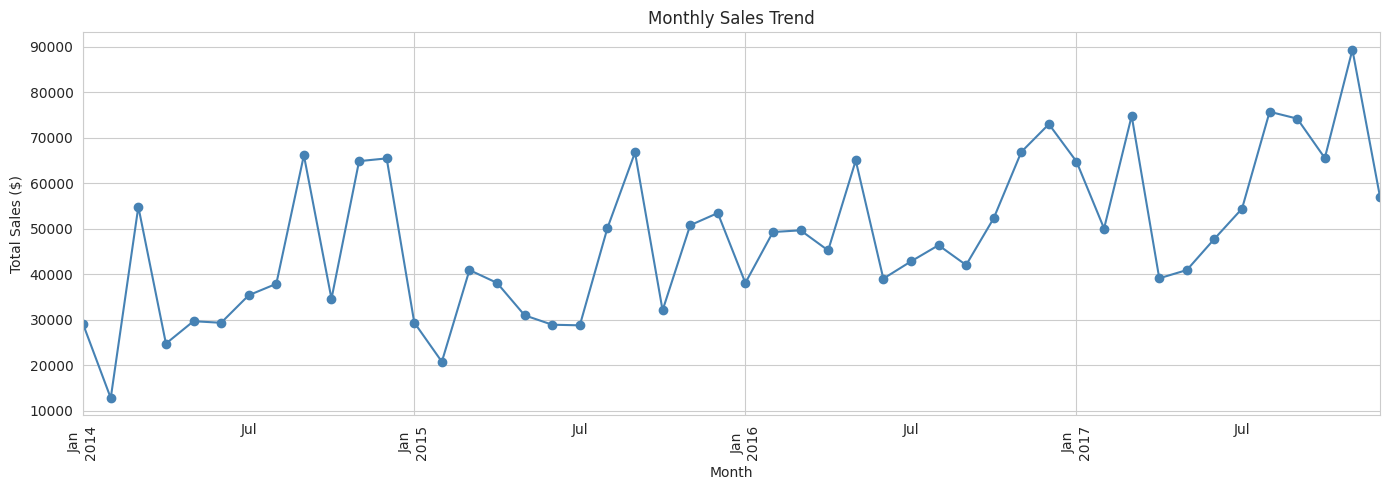

In [5]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


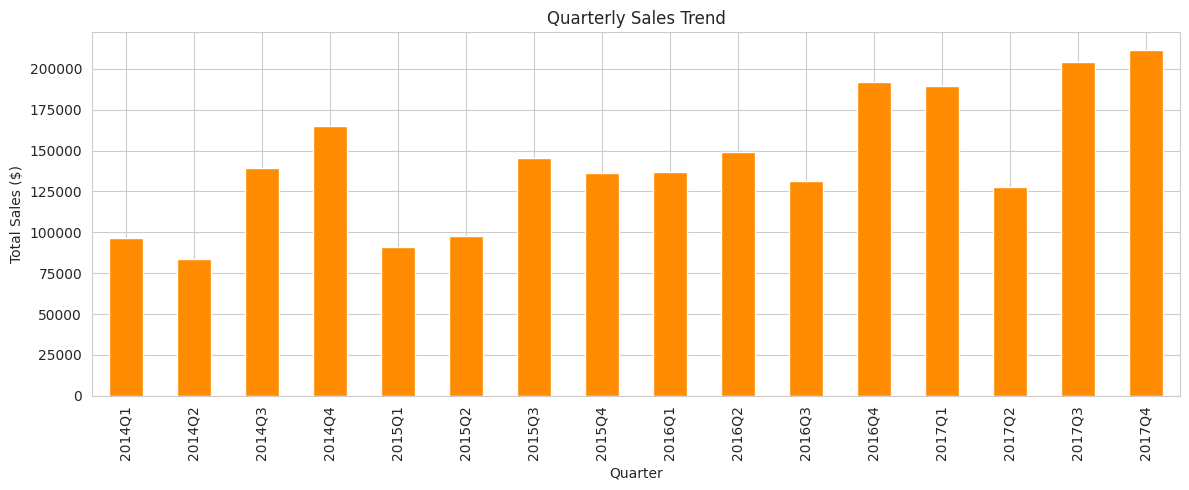

In [6]:
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(12,5))
quarterly_sales.plot(kind='bar', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** Sales show a clear seasonal pattern — Q4 (Oct–Dec) is consistently the strongest quarter across all years, likely driven by holiday-season purchasing, while Q1 is consistently the weakest. There's also an overall upward trend year-over-year, suggesting the business is growing.

## 4. Customer Demographics Analysis
**Note:** This dataset does not include individual customer age or gender fields, so we substitute the closest available demographic-style breakdowns: **Customer Segment** (Consumer / Corporate / Home Office) and **Region**.

/tmp/ipykernel_532/310659210.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, ax=axes[1], palette='pastel')


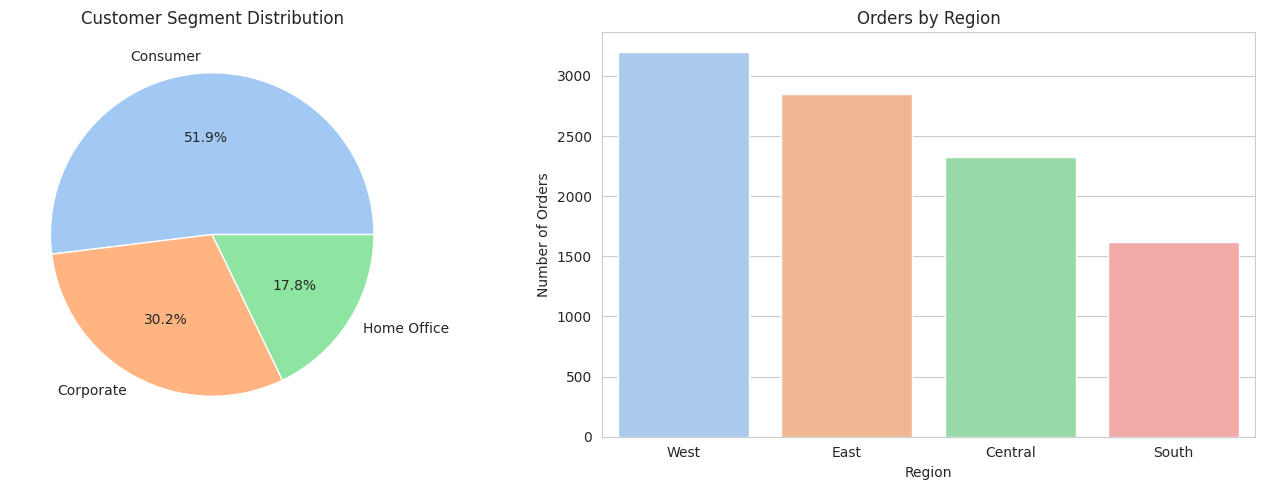

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

segment_counts = df['Segment'].value_counts()
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
axes[0].set_title('Customer Segment Distribution')

region_counts = df['Region'].value_counts()
sns.barplot(x=region_counts.index, y=region_counts.values, ax=axes[1], palette='pastel')
axes[1].set_title('Orders by Region')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()


**Observation:** The **Consumer** segment makes up roughly half of all orders, well ahead of Corporate and Home Office. Geographically, the **West** and **East** regions generate the most orders, while the **South** lags behind — a useful signal for regional marketing focus.

## 5. Product Analysis
Top 10 best-selling products and revenue by category.

/tmp/ipykernel_532/394347973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_products.values, y=top10_products.index, palette='viridis')


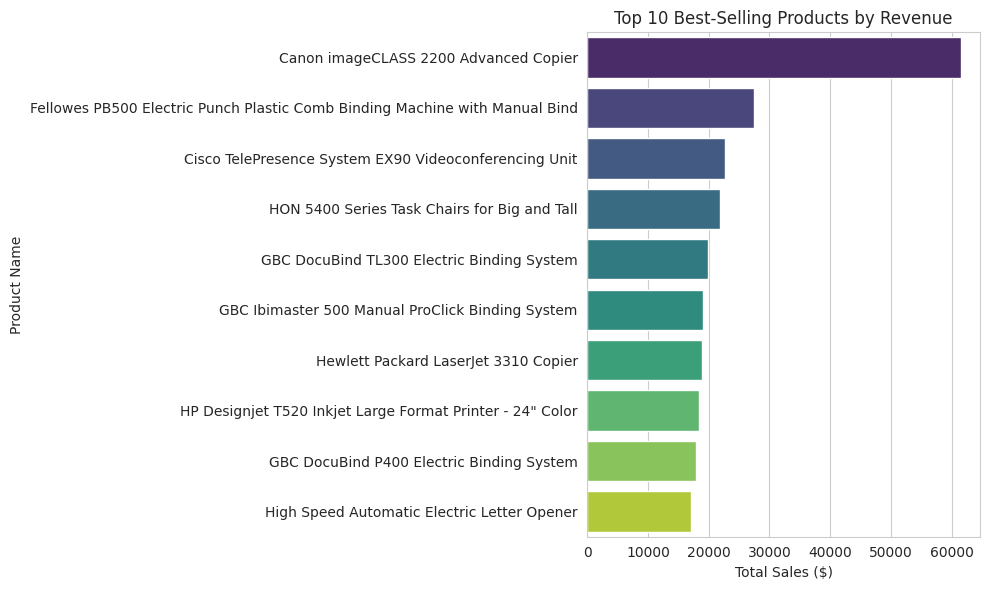

In [8]:
top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_products.values, y=top10_products.index, palette='viridis')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_532/685232914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='Set2')


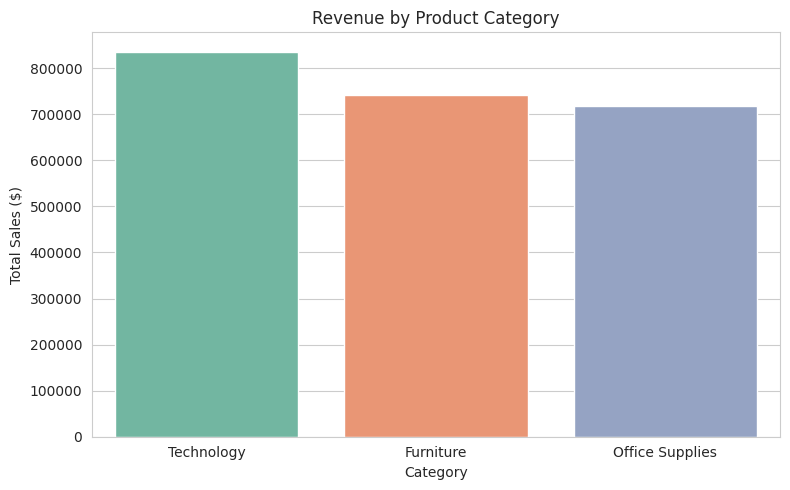

In [9]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='Set2')
plt.title('Revenue by Product Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** **Technology** and **Office Supplies** are the top two revenue-generating categories, with high-end items like Copiers and Phones each individually contributing large single-product revenue spikes in the top-10 list. Furniture generates decent revenue too, but (as we'll see next) its profit margins tell a different story.

## 6. Correlation Heatmap
Relationship between the numerical variables.

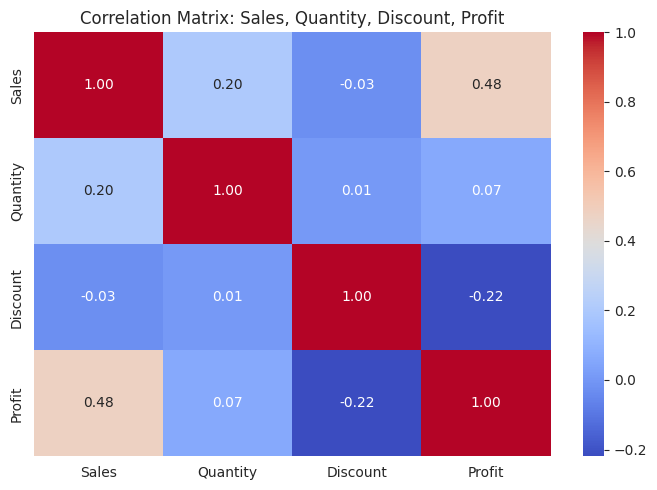

In [10]:
plt.figure(figsize=(7,5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.show()


**Observation:** Sales and Profit are moderately positively correlated, as expected. Notably, **Discount has a negative correlation with Profit** — the higher the discount applied, the lower (or more negative) the profit tends to be. This hints that the discounting strategy may be eroding margins.

## 7. Additional Insight — Profitability by Sub-Category
The category-level view hides an important detail: some sub-categories are consistently unprofitable. Let's dig deeper.

/tmp/ipykernel_532/2498656223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette=colors)


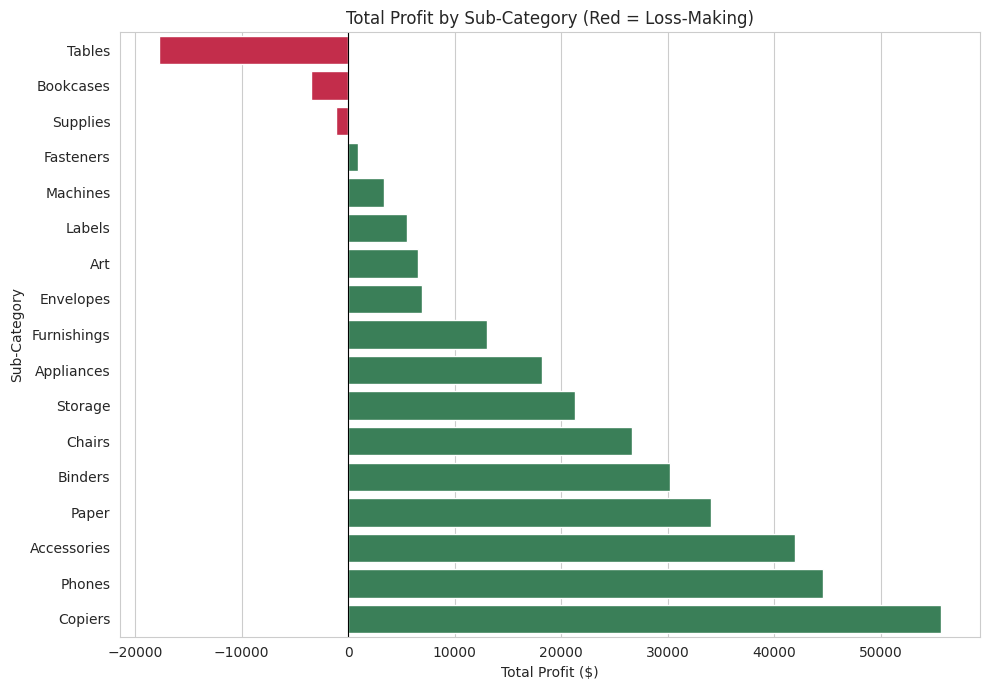

In [11]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,7))
colors = ['crimson' if v < 0 else 'seagreen' for v in subcat_profit.values]
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette=colors)
plt.title('Total Profit by Sub-Category (Red = Loss-Making)')
plt.xlabel('Total Profit ($)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


**Observation (non-obvious insight):** While Technology and Office Supplies looked strong at the category level, several **sub-categories are actually losing money overall** — most notably **Tables** and **Bookcases**, which show large aggregate losses. This is hidden when looking only at category-level revenue and only becomes visible at the sub-category level, and it's a strong signal that these product lines may be over-discounted or poorly priced.

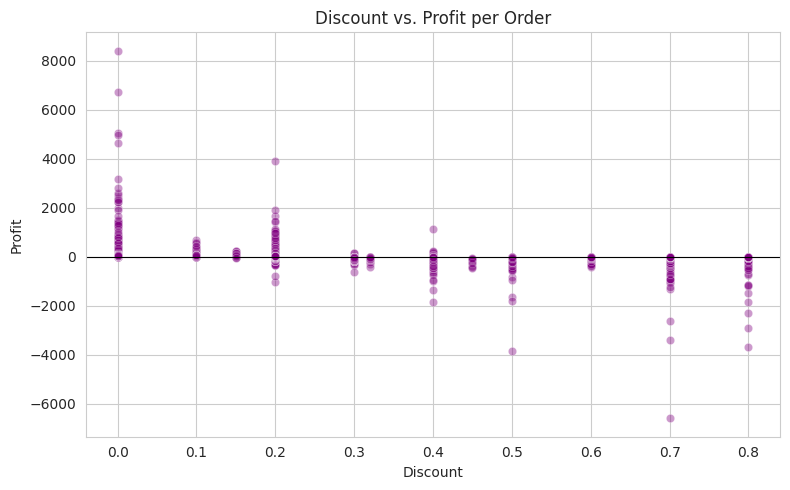

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='purple')
plt.title('Discount vs. Profit per Order')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


**Observation:** Orders with discounts above ~30% overwhelmingly fall into negative profit territory. This visually confirms the correlation seen in the heatmap and pinpoints a rough discount threshold (~30%) beyond which orders tend to become unprofitable.

## 8. Conclusion — Actionable Business Recommendations

Based on the analysis above, here are three specific, actionable recommendations:

1. **Cap discounts on Tables and Bookcases, or re-price them.** These sub-categories are consistently loss-making in aggregate, and the discount-vs-profit analysis shows profitability collapses once discounts exceed ~30%. A discount ceiling (e.g. 15–20%) on these specific sub-categories would likely recover meaningful margin.

2. **Double down on Q4 seasonal demand.** Sales consistently peak in Q4 across all years. The business should front-load inventory and marketing spend for Technology and Office Supplies (the top revenue categories) ahead of Q4 to capture this predictable seasonal surge, rather than spreading marketing budget evenly across the year.

3. **Grow the South region and Corporate/Home Office segments.** The South region and the Corporate/Home Office customer segments currently under-index compared to the West/East regions and the Consumer segment. Targeted regional marketing or a B2B-focused sales push could unlock underexploited revenue in these segments.

---
*This notebook fulfils the Level 1 — Task 1 (EDA on Retail Sales Data) checklist for the Oasis Infobyte Data Analytics SIP track.*
